# ORNL Telemetry Data Across All Caps using Arkouda

This is an attempt to transliterate the code in Data_across_All_Caps.ipynb that uses pandas into arkouda.

In [1]:
import arkouda as ak
ak.connect("x1002c0s2b0n0")

    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          

Client Version: v2025.01.13+47.g459392748.dirty


connected to arkouda server tcp://*:5555


In [2]:
dir = "/lus/scratch/khandeka/hpegithub/ORNL-telemetry-analysis/parquet-traces-for-LSMS-application/"

power_cap200 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_200_16_events.parquet"
power_cap300 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_300_16_events.parquet"
power_cap400 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_400_16_events.parquet"
power_cap500 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_500_16_events.parquet"
power_cap600 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_600_16_events.parquet"
power_cap700 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_700_16_events.parquet"
power_cap800 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_800_16_events.parquet"
power_cap900 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_900_16_events.parquet"
power_cap1000 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_1000_16_events.parquet"

# List of power cap files
power_caps = [power_cap200, power_cap300, power_cap400, power_cap500, power_cap600, power_cap700, power_cap800, power_cap900, power_cap1000]
# power_caps = [power_cap1000]

power_cap_names = [name.split('_')[-3] for name in power_caps[::-1]]
print(power_cap_names)  # Output: ['800', '900', '1000']

['1000', '900', '800', '700', '600', '500', '400', '300', '200']


In [3]:
def read_parquet_and_drop_columns(file_path):
    ak_df = ak.read_parquet(file_path)
    # Drop the columns we don't need
    keys_to_keep = ['time', 'metric', 'values', 'region', 'location', 'event']
    ak_df = {key: ak_df[key] for key in keys_to_keep}
    ak_df = ak.DataFrame(ak_df)
    return ak_df

In [4]:
def preprocess_power_data(df):
    df = df[df["values"] != "nan"]
    df['values'] = df['values'].strip('[]').astype(ak.float64) / 1000 # convert miliwatts to watts
    return df

def find_leave_events(df):
    leave_events = df[df["event"] == "Leave"]
    leave_events = leave_events.sort_values("time")
    return leave_events

#### Note on the difference in approach when using Arkouda
Iterating directly over a DataFrame with `for x in df` is not recommended. Doing so is discouraged because it requires transferring all array data from the arkouda server to the Python client since there is almost always a more array-oriented way to express an iterator-based computation.

In [ ]:
import arkouda.array_api as xp
import numpy as np
import time as time

def getInclusiveEnergy(df, df_power):
    df_power = preprocess_power_data(df_power)
    start_time = time.time()
    duration_time = 0
    last_tracked_energies_time = 0
    energy_mask_time = 0
    energy_df_slices_time = 0
    trapz_vectorized_time = 0

    regions = ak.unique(df['region'])
    # print(regions)

    # Storing the total energy and time for each region in pdarrays
    region_times = ak.zeros(len(regions), dtype=ak.float64)
    region_energies = ak.zeros(len(regions), dtype=ak.float64)
    print(f"Number of regions: {len(regions)}")
    # The data has 36 (?) or so unique regions, so we can loop over them like this without it being terrible
    # We could also sort the data by region and then just slice into the df instead of having to make multiple linear searches
    # But that's a potential future optimization
    for i, region in enumerate(regions.to_ndarray()):
        df_r = df[df['region'] == region]
        # print(f"Region: {region}, Number of data points: {df_r}")
        if df.size == 0:
            print(f"Region: {region}, has no data points, skipping")
            continue

        dur_start = time.time()

        enter_events = df_r[df_r['event'] == 'Enter']
        leave_events = find_leave_events(df_r)

        leave_times = leave_events['time']
        # leave_regions = leave_events['region'] # This is not needed since region will be the same in this loop

        enter_times = enter_events["time"]
        # enter_regions = enter_events["region"] # This is not needed since region will be the same in this loop

        """"
        enter time: 35 (k1)
        enter time: 35 (k2)

        leave times10 20 30 35 40 40 50
                               k2 k1
        """
        leave_indices = xp.searchsorted(xp.asarray(leave_times), xp.asarray(enter_times), side="left")._array # Bug in searchsorted. Meaning of side="left" and side="right" is swapped

        valid_indices = (leave_indices < len(leave_times)) #& (leave_regions[leave_indices] == enter_regions)

        valid_enter_times = enter_times[valid_indices]
        valid_leave_times = leave_times[valid_indices]
        # valid_regions     = enter_regions[valid_indices] # Not needed in this version since the loop is over regions

        durations = valid_leave_times - valid_enter_times
        total_region_time = ak.sum(durations)
        region_times[i] = total_region_time  # Accumulate time for each region

        duration_time += time.time() - dur_start
        # print(f"Runtime for durations: {time.time() - dur_start:.4f} seconds")

        lte_start = time.time()

        # Vectorized energy calculation
        power_data_indices = xp.searchsorted(xp.asarray(df_power['time']), xp.asarray(valid_enter_times), side="right")._array # Bug in searchsorted. Meaning of side="left" and side="right" is swapped
        power_data_indices = ak.where(power_data_indices <= 0, len(df_power['values']) - (power_data_indices+1), power_data_indices) # Indices less than 0 wrap around automatically, this seems to be technically incorrect, is a bug?
        last_tracked_powers = df_power['values'][power_data_indices] # missing -1 here
        last_tracked_energies = last_tracked_powers * durations

        last_tracked_energies_time += time.time() - lte_start
        # print(f"Runtime for last Tracked Energies: {time.time() - lte_start:.4f} seconds")

        mask_time = time.time()

        # Create a mask to filter out the power data for each region
        # This is a 2D mask, where each row corresponds to a region and each column corresponds to a power data point
        # Calculating this is also slow in Arkouda, needs investigation
        energy_mask = (df_power['time'] >= valid_enter_times[:, None]) & (df_power['time'] <= valid_leave_times[:, None])
        power_data_not_empty = ak.any(energy_mask, axis=1)

        energy_mask_time += time.time() - mask_time
        # print(f"Runtime for energy mask: {time.time() - mask_time:.4f} seconds")

        slice_time = time.time()

        energy_values = ak.where(energy_mask, df_power['values'][:, None], ak.nan)
        energy_times = ak.where(energy_mask, df_power['time'][:, None], ak.nan)

        energy_df_slices_time += time.time() - slice_time
        # print(f"Runtime for energy df slices: {time.time() - slice_time:.4f} seconds")

        trapz_time = time.time()

        energies = xp.trapz(xp.asarray(energy_values), xp.asarray(energy_times), axis=1, ignore_nan=True)._array

        energies = ak.where(power_data_not_empty, energies, last_tracked_energies)

        trapz_vectorized_time = time.time() - trapz_time
        # print(f"Runtime for trapz vectorized: {time.time() - trapz_time:.4f} seconds")

        # total_region_energy = ak.sum(energies) # FIXME
        total_region_energy = ak.sum(last_tracked_energies) # Bug in the integration, using this as placeholder for performance testing
        region_energies[i] = total_region_energy  # Accumulate energy for each region

        # print("Region Energy: ", total_region_energy)
        # print("Region Time: ", total_region_time)

    print("Region Energies: ", region_energies)
    print("Region Times: ", region_times)

    energy_data = {
        'region': regions,
        'energy': region_energies,
        'duration': region_times
    }
    print(energy_data)
    df_energies = ak.DataFrame(energy_data)
    df_energies = df_energies.sort_values('energy', ascending=False)
    df_energies = df_energies[df_energies['energy'] > 1.0]

    end_time = time.time()
    runtime = end_time - start_time
    print(f"Runtime: {runtime:.2f} seconds")
    print(f"Durations Time: {duration_time:.2f} seconds")
    print(f"Last Tracked Energies Time: {last_tracked_energies_time:.2f} seconds")
    print(f"Energy Mask Time: {energy_mask_time:.2f} seconds")
    print(f"Energy DF Slices Time: {energy_df_slices_time:.2f} seconds")
    print(f"Trapz Vectorized Time: {trapz_vectorized_time:.2f} seconds")

    # There might be a bug here
    df_energies_pandas = df_energies.to_pandas(retain_index=True)
    print(df_energies_pandas)

    # Output the regions and their total energies
    print("\n=== Total Energy per Region ===")
    for region_name, energy, total_time in zip(df_energies_pandas['region'], df_energies_pandas['energy'], df_energies_pandas['duration']):
        print(f"Region: {region_name}, Total Energy: {energy:.2f} J, Total Time: {total_time:.2f} s")

    return df_energies_pandas.head(8) # I just do to_pandas here to minimize the amount of data that needs to be transferred back to the client


/lus/bnchlu1/khandeka/arkouda/arkouda/array_api/__init__.py:287: UserWarning: The arkouda.array_api submodule is still experimental.
  warnings.warn("The arkouda.array_api submodule is still experimental.")


In [ ]:
def get_avg_power(df_energies):
    # Add the avg power column to the same DataFrame
    # Nice for a demo, but you would just do the division here instead of using assign
    # df_energies.assign(avg_power=lambda x: (x['energy']*x['duration']))

    return {region: avg_power for region, avg_power in zip(df_energies['region'].values, df_energies['energy'].values/df_energies['duration'].values)}


In [ ]:
def get_speedup_perf_drop(df_energies, baseline):
    speedup_energy = {}
    performance_drop = {}
    energy_saved = {}

    for _, row in df_energies.iterrows():
        region = row['region']
        energy = row['energy']
        runtime = row['duration']
        baseline_runtime = baseline.loc[baseline['region'] == region, 'duration'].values[0]
        baseline_energy = baseline.loc[baseline['region'] == region, 'energy'].values[0]

        if baseline_runtime and baseline_energy and runtime and energy:
            speedup = (baseline_runtime * baseline_energy) / (runtime * energy)
            energy_saved[region] = 100 * (energy - baseline_energy) / baseline_energy if energy != 0 else None
            performance_drop[region] = 100 * (runtime - baseline_runtime) / baseline_runtime if runtime != 0 else None
        else:
            speedup = None
            energy_saved[region] = None
            performance_drop[region] = None

        speedup_energy[region] = speedup

    return energy_saved, performance_drop, speedup_energy


In [ ]:
avg_power_data = {}
energy_saved_data = {}
performance_drop_data = {}
speedup_energy_data = {}

for cap in power_caps[::-1]:
    df_events = read_parquet_and_drop_columns(dir+cap)

    df_events["time"] = df_events["time"].astype(ak.int64) # Convert time to seconds
    df_events["time"] = (df_events['time'] - df_events['time'][0]) / 1000000000

    df_gpupower = df_events[df_events["metric"] == "MetricInstance [21]: 'metric_class': MetricClass [20], 'recorder': Location [47244640256] '', 'metric_scope': MetricScope.SYSTEM_TREE_NODE, 'scope': SystemTreeNode [1] 'wombat35'"].copy()

    regions = df_events[df_events["region"] != "nan"]  # Filter out rows where region is NaN
    df_gpuevents = regions[regions["location"] == "CUDA[0:7]"].copy()

    df_energies = getInclusiveEnergy(df_gpuevents, df_gpupower)

    if cap == power_cap1000:
        baseline = df_energies

    # use arrays and dataframes
    avg_power = get_avg_power(df_energies)
    energy_saved, performance_drop, speedup_energy  = get_speedup_perf_drop(df_energies, baseline)

    # Store metrics for each region across power caps
    for region in df_energies['region'].values:
        if region not in avg_power_data:
            avg_power_data[region] = []
            energy_saved_data[region] = []
            performance_drop_data[region] = []
            speedup_energy_data[region] = []

        avg_power_data[region].append(avg_power.get(region, None))
        energy_saved_data[region].append(energy_saved.get(region, None))
        performance_drop_data[region].append(performance_drop.get(region, None))
        speedup_energy_data[region].append(speedup_energy.get(region, None))


Number of regions: 36
Region Energies:  [110.765 3.31705 1094.86 177.06 108.417 0.0978679 15.5928 970.289 2329.85 5194.46 1.21596 2.00866 2227.55 720.368 284.73 0.106728 463.252 42.6039 540.236 66.9076 4655.86 53.7295 162.347 48.7672 49.1277 0.260019 198.455 4.1072 20557.7 109.295 411.305 66.2381 43029.3 0.174818 89.2963 2050.86]
Region Times:  [0.183979 0.00606366 1.82395 0.294904 0.188005 0.000178528 0.0259125 1.70157 4.0674 8.88717 0.00206872 0.00335297 4.06667 1.20135 0.474103 0.000177376 0.769628 0.0741191 0.897979 0.122258 8.02751 0.0980803 0.27036 0.0813045 0.0818016 0.000432096 0.336937 0.0068234 34.9092 0.181564 0.698041 0.113196 77.7927 0.000290496 0.148353 3.57434]
{'region': array(['getrf_pivot<getrf_params_<double2, 512, 3, 512, 256, 1> >', 'copyTMatrixToTauCuda', 'getrf_pivot<getrf_params_<double2, 512, 2, 512, 64, 8> >', 'sm90_xmma_gemm_cf64cf64_f64f64_cf64_nn_n_tilesize32x16x64_stage3_warpsize2x1x2_tensor16x8x16_execute_split_k_kernel__5x_cublas', 'sm90_xmma_gemm_cf64cf

The performance here is weird.
1. `trapz` is slow, we need to fix that no matter what.

    `diff` is the slow part. Took 4 minutes and 30 seconds on a single locale in vectorized approach. Gotta make it go faster. Much faster.

    Fixed by parallalizing `diff`


2. The broadcast operations (which use 2D arrays in Arkouda) are also slow, and they get slower when increasing numlocales.
    Ex: with one locale, we have:
    ```
    Runtime: 186.81 seconds
    Durations Time: 7.29 seconds
    Last Tracked Energies Time: 0.93 seconds
    Energy Mask Time: 63.75 seconds
    Energy DF Slices Time: 32.00 seconds
    Trapz Vectorized Time: 10.28 seconds
    ```

    But upping that to just two locales (same amount of data actually being worked on):

    ```
    Runtime: 594.91 seconds
    Durations Time: 16.35 seconds
    Last Tracked Energies Time: 3.01 seconds
    Energy Mask Time: 367.95 seconds
    Energy DF Slices Time: 25.34 seconds
    Trapz Vectorized Time: 21.07 seconds
    ```
    Which is crazy!!
    In my observation of this run, there a `broadcast` call which takes the most amount of time, `binopvv` is pretty fast.




Plotting code would be the same

/tmp/ipykernel_3962147/3495046069.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="best")


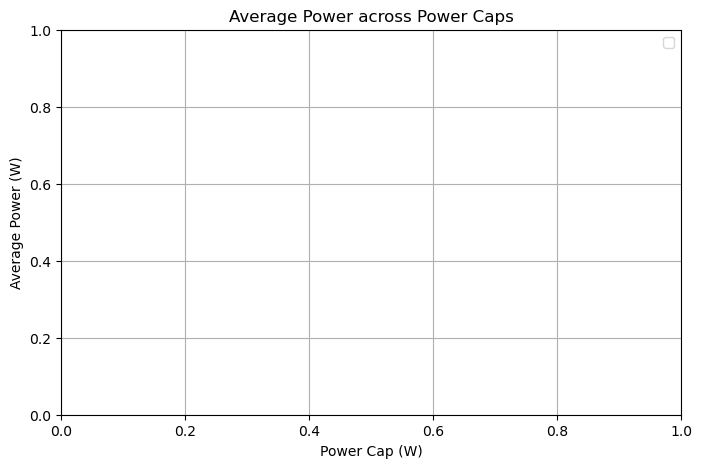

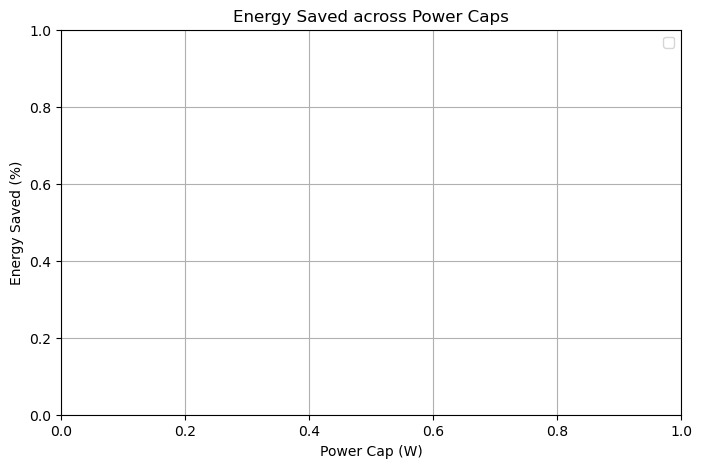

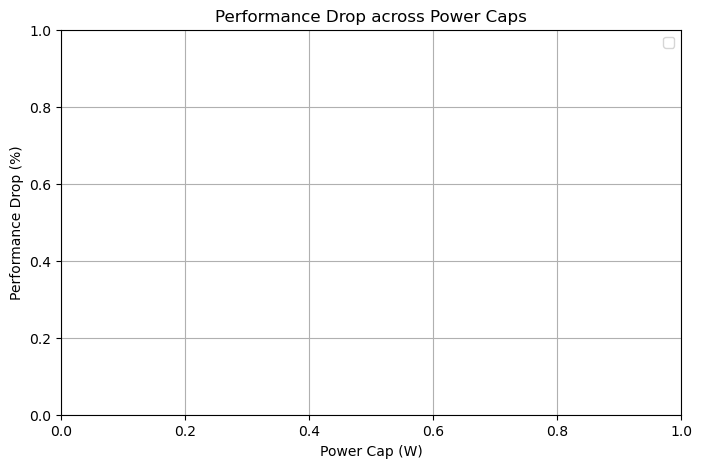

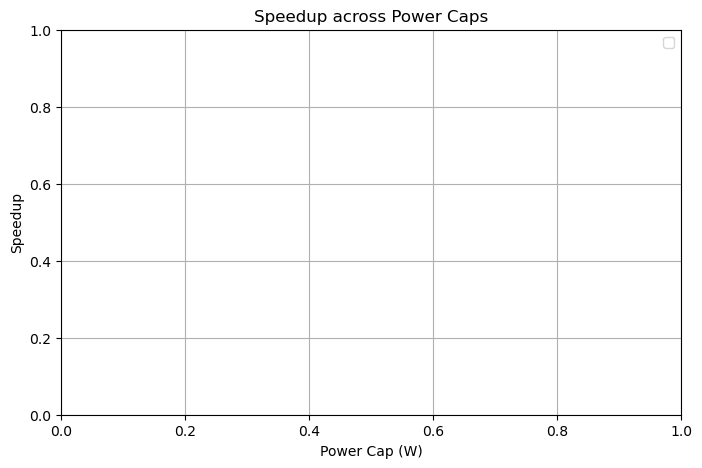

In [ ]:
import matplotlib.pyplot as plt

# Plotting function
def plot_metric_across_power_caps(data, title, ylabel):
    plt.figure(figsize=(8, 5))
    for region, values in data.items():
        if region == "COMPUTE IDLE":
            continue
        # Shorten the region name for the legend
        short_region = region[:15] + "..." if len(region) > 15 else region
        plt.plot(power_cap_names, values, marker='o', label=short_region)
    plt.xlabel("Power Cap (W)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Plot each metric
plot_metric_across_power_caps(avg_power_data, "Average Power across Power Caps", "Average Power (W)")
plot_metric_across_power_caps(energy_saved_data, "Energy Saved across Power Caps", "Energy Saved (%)")
plot_metric_across_power_caps(performance_drop_data, "Performance Drop across Power Caps", "Performance Drop (%)")
plot_metric_across_power_caps(speedup_energy_data, "Speedup across Power Caps", "Speedup")